In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

import mne
from mne.datasets.sleep_physionet.age import fetch_data

In [39]:
# path = "dataset/sampleedf/Pt1_S2-end.edf"
# signals, signal_headers, header = highlevel.read_edf(path)

# print(signals[0])
# print(header)

Using default location ~/mne_data for PHYSIONET_SLEEP...


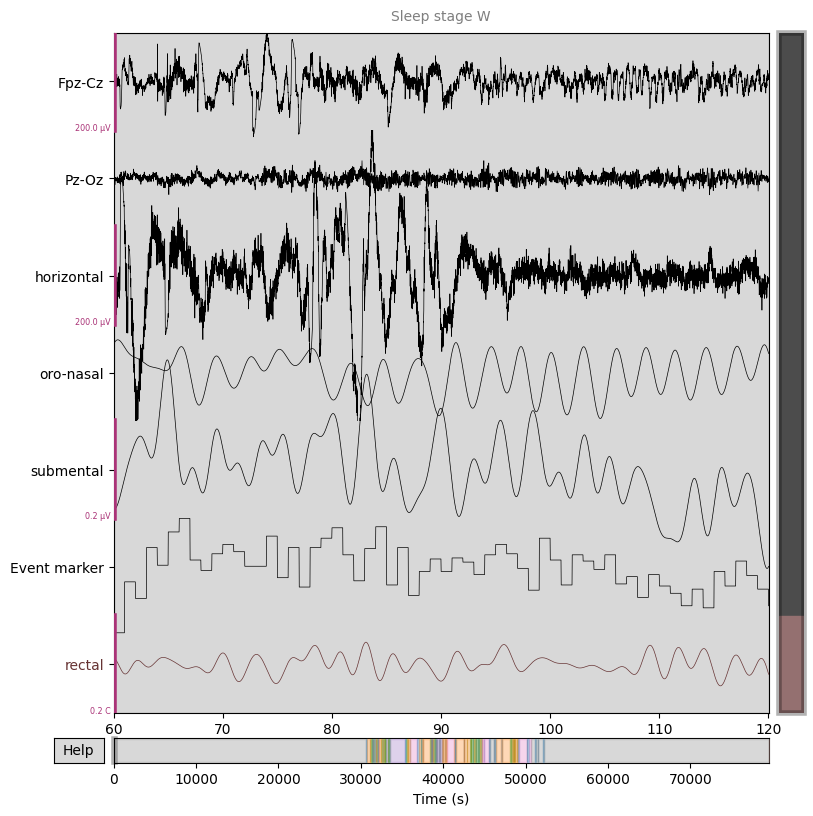

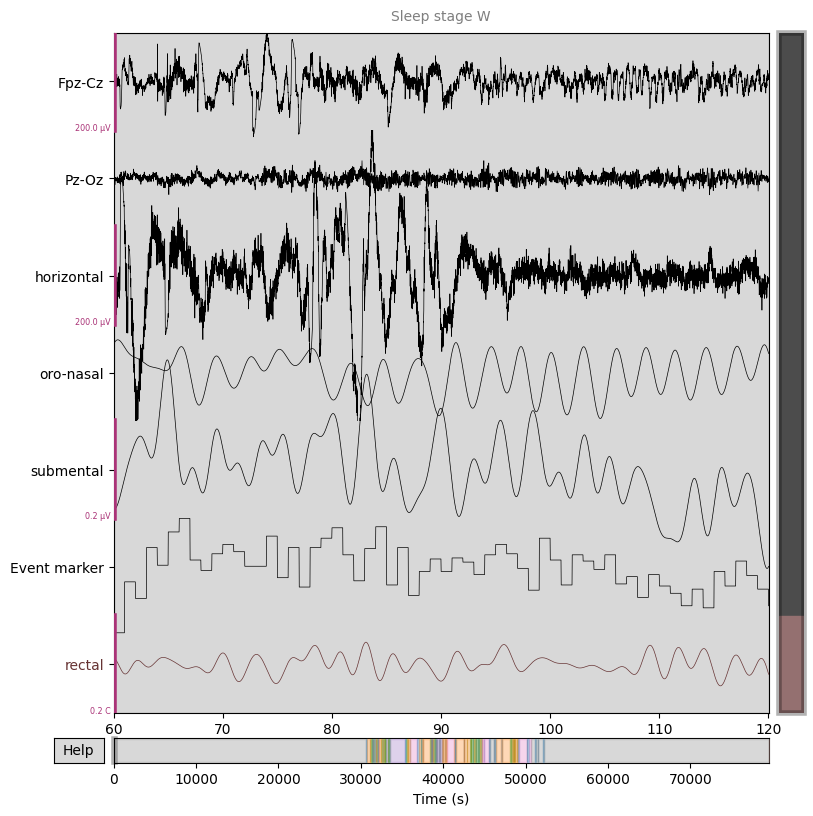

In [40]:
ALICE, BOB = 0, 1
# The subjects to use. Can be in the range of 0-82 (inclusive), however
# the following subjects are not available: 39, 68, 69, 78 and 79.

[alice_files, bob_files] = (
    fetch_data(subjects=[ALICE, BOB], recording=[1])
)

raw_train_alice = mne.io.read_raw_edf(
    alice_files[0],
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error",  # ignore issues with stored filter settings
)
annot_train_alice = mne.read_annotations(alice_files[1])

raw_train_alice.set_annotations(annot_train_alice, emit_warning=False)

# plot some data
# scalings were chosen manually to allow for simultaneous visualization of
# different channel types in this specific dataset
raw_train_alice.plot(
    start=60,
    duration=60,
    scalings=dict(eeg=1e-4, resp=1e3, eog=1e-4, emg=1e-7, misc=1e-1),
)

In [41]:
alice_files[0]

'/home/mehmet/mne_data/physionet-sleep-data/SC4001E0-PSG.edf'

In [42]:
alice_files[1]

'/home/mehmet/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf'

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]


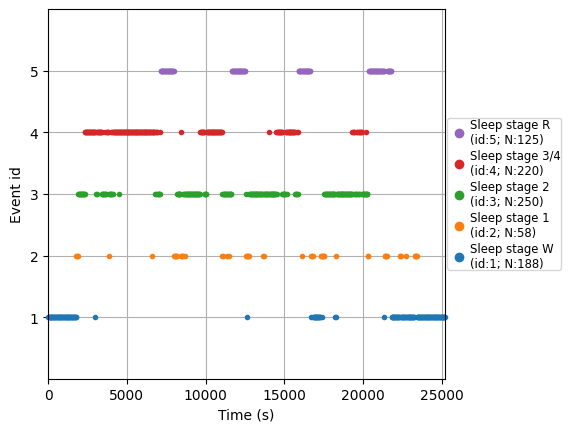

In [43]:
annotation_desc_2_event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
}

# keep last 30-min wake events before sleep and first 30-min wake events after
# sleep and redefine annotations on raw data
annot_train_alice.crop(annot_train_alice[1]["onset"] - 30 * 60, annot_train_alice[-2]["onset"] + 30 * 60)
raw_train_alice.set_annotations(annot_train_alice, emit_warning=False)

events_train_alice, _ = mne.events_from_annotations(
    raw_train_alice, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)

# create a new event_id that unifies stages 3 and 4
event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3/4": 4,
    "Sleep stage R": 5,
}

# plot events
fig = mne.viz.plot_events(
    events_train_alice,
    event_id=event_id,
    sfreq=raw_train_alice.info["sfreq"],
    first_samp=events_train_alice[0, 0],
)

# keep the color-code for further plotting
stage_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [44]:
tmax = 30.0 - 1.0 / raw_train_alice.info["sfreq"]  # tmax in included

epochs_train_alice = mne.Epochs(
    raw=raw_train_alice,
    events=events_train_alice,
    event_id=event_id,
    tmin=0.0,
    tmax=tmax,
    baseline=None,
)
del raw_train_alice

print(epochs_train_alice)

Not setting metadata
841 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 841 events (good & bad), 0 – 29.99 s (baseline off), ~11 KiB, data not loaded,
 'Sleep stage W': 188
 'Sleep stage 1': 58
 'Sleep stage 2': 250
 'Sleep stage 3/4': 220
 'Sleep stage R': 125>


In [45]:
raw_test_bob = mne.io.read_raw_edf(
    bob_files[0],
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error",
)
annot_test_bob = mne.read_annotations(bob_files[1])
annot_test_bob.crop(annot_test_bob[1]["onset"] - 30 * 60, annot_test_bob[-2]["onset"] + 30 * 60)
raw_test_bob.set_annotations(annot_test_bob, emit_warning=False)
events_test_bob, _ = mne.events_from_annotations(
    raw_test_bob, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)
epochs_test_bob = mne.Epochs(
    raw=raw_test_bob,
    events=events_test_bob,
    event_id=event_id,
    tmin=0.0,
    tmax=tmax,
    baseline=None,
)
del raw_test_bob

print(epochs_test_bob)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
1103 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 1103 events (good & bad), 0 – 29.99 s (baseline off), ~11 KiB, data not loaded,
 'Sleep stage W': 157
 'Sleep stage 1': 109
 'Sleep stage 2': 562
 'Sleep stage 3/4': 105
 'Sleep stage R': 170>


In [46]:
def eeg_power_band(epochs):
    """EEG relative power band feature extraction.

    This function takes an ``mne.Epochs`` object and creates EEG features based
    on relative power in specific frequency bands that are compatible with
    scikit-learn.

    Parameters
    ----------
    epochs : Epochs
        The data.

    Returns
    -------
    X : numpy array of shape [n_samples, 5 * n_channels]
        Transformed data.
    """
    # specific frequency bands
    FREQ_BANDS = {
        "delta": [0.5, 4.5],
        "theta": [4.5, 8.5],
        "alpha": [8.5, 11.5],
        "sigma": [11.5, 15.5],
        "beta": [15.5, 30],
    }

    spectrum = epochs.compute_psd(picks="eeg", fmin=0.5, fmax=30.0)
    psds, freqs = spectrum.get_data(return_freqs=True)
    # Normalize the PSDs
    psds /= np.sum(psds, axis=-1, keepdims=True)

    X = []
    for fmin, fmax in FREQ_BANDS.values():
        psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
        X.append(psds_band.reshape(len(psds), -1))

    return np.concatenate(X, axis=1)

In [47]:
pipe = make_pipeline(
    FunctionTransformer(eeg_power_band, validate=False),
    RandomForestClassifier(n_estimators=100, random_state=42),
)

# Train
y_train_alice = epochs_train_alice.events[:, 2]
pipe.fit(epochs_train_alice, y_train_alice)

# Test
y_pred_bob = pipe.predict(epochs_test_bob)

# Assess the results
y_test_bob = epochs_test_bob.events[:, 2]
acc = accuracy_score(y_test_bob, y_pred_bob)

print(f"Accuracy score: {acc}")

Using data from preloaded Raw for 841 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Using data from preloaded Raw for 1103 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Accuracy score: 0.6727107887579329


In [48]:
print(confusion_matrix(y_test_bob, y_pred_bob))

[[153   1   1   2   0]
 [ 71  26   8   0   4]
 [ 50  36 429  24  23]
 [  0   0   3 102   0]
 [ 51  70  17   0  32]]


In [49]:
print(classification_report(y_test_bob, y_pred_bob, target_names=event_id.keys()))

                 precision    recall  f1-score   support

  Sleep stage W       0.47      0.97      0.63       157
  Sleep stage 1       0.20      0.24      0.21       109
  Sleep stage 2       0.94      0.76      0.84       562
Sleep stage 3/4       0.80      0.97      0.88       105
  Sleep stage R       0.54      0.19      0.28       170

       accuracy                           0.67      1103
      macro avg       0.59      0.63      0.57      1103
   weighted avg       0.72      0.67      0.67      1103

